# Notebook 2: Text Preprocessing Pipeline
**Project:** Sentiment Analysis on Trustpilot Marketing Reviews  
**Client:** Candy Factory Group – Pannipitiya  
**Input:** `data/processed/reviews_labelled.csv`  
**Output:** `data/processed/reviews_cleaned.csv`

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import os
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../reports/figures', exist_ok=True)

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

sns.set_theme(style="whitegrid")
print("Libraries loaded")

Libraries loaded


## 2. Load Labelled Dataset

In [13]:
df = pd.read_csv('../data/processed/reviews_labelled.csv')

# Re-parse datetime if needed
df['reviewed_at'] = pd.to_datetime(df['reviewed_at'], errors='coerce')

# Ensure review_length exists (in case notebook is run independently)
df['review_length'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))

print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df[['review_text', 'rating', 'sentiment']].head(5)

Shape   : (3698, 13)
Columns : ['name', 'company_url', 'trustpilot_url', 'description', 'author_name', 'review_title', 'review_text', 'rating', 'reviewed_at', 'uniq_id', 'scraped_at', 'sentiment', 'review_length']


,review_text,rating,sentiment
0,Lowest price in the country for what we wanted...,5,Positive
1,got it on time they took notice that I let the...,5,Positive
2,"Delivered on time. Products as described, pack...",5,Positive
3,Quick and efficient service..Pleased,5,Positive
4,Excellent service packed well. Really pleased.,5,Positive


## 2.5 Data Cleaning - Missing Values, Duplicates & Outliers

In [14]:
print("=== Missing Values Before Cleaning ===")
print(df.isnull().sum())
print(f"\nTotal rows before cleaning: {len(df)}")

=== Missing Values Before Cleaning ===
name                0
company_url         0
trustpilot_url      0
description       686
author_name         1
review_title        0
review_text         0
rating              0
reviewed_at       192
uniq_id             0
scraped_at          0
sentiment           0
review_length       0
dtype: int64

Total rows before cleaning: 3698


In [15]:
# Drop rows where review_text is null — essential for NLP
df.dropna(subset=['review_text'], inplace=True)

# Fill missing review_title with empty string (They will be combined later)
df['review_title'] = df['review_title'].fillna('')

# Fill missing author_name with 'Anonymous'
df['author_name'] = df['author_name'].fillna('Anonymous')

# Fill missing description with empty string
df['description'] = df['description'].fillna('')

# Convert to datetime
df['reviewed_at'] = pd.to_datetime(df['reviewed_at'], errors='coerce')
df['scraped_at'] = pd.to_datetime(df['scraped_at'], errors='coerce')

# Fill missing reviewed_at using scraped_at
df['reviewed_at'] = df['reviewed_at'].fillna(df['scraped_at'])

print(df['reviewed_at'].isnull().sum())

print("=== Missing Values After Cleaning ===")
print(df.isnull().sum())
print(f"\nTotal rows after null handling: {len(df)}")

0
=== Missing Values After Cleaning ===
name              0
company_url       0
trustpilot_url    0
description       0
author_name       0
review_title      0
review_text       0
rating            0
reviewed_at       0
uniq_id           0
scraped_at        0
sentiment         0
review_length     0
dtype: int64

Total rows after null handling: 3698


In [16]:
# Check for duplicate reviews (same review_text and same author)
duplicates = df.duplicated(subset=['review_text', 'author_name'], keep='first')
print(f"Duplicate rows found : {duplicates.sum()}")

df.drop_duplicates(subset=['review_text', 'author_name'], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Total rows after duplicate removal: {len(df)}")

Duplicate rows found : 0
Total rows after duplicate removal: 3698


In [17]:
# Flag reviews that are too short (< 3 words) or too long (> 300 words)
df['review_length'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))

too_short = (df['review_length'] < 3).sum()
too_long  = (df['review_length'] > 300).sum()

print(f"Reviews with < 3 words   : {too_short}  -> removing")
print(f"Reviews with > 300 words : {too_long}  -> removing")

df = df[(df['review_length'] >= 3) & (df['review_length'] <= 300)].reset_index(drop=True)

print(f"\nTotal rows after outlier removal: {len(df)}")

Reviews with < 3 words   : 88  -> removing
Reviews with > 300 words : 24  -> removing

Total rows after outlier removal: 3586


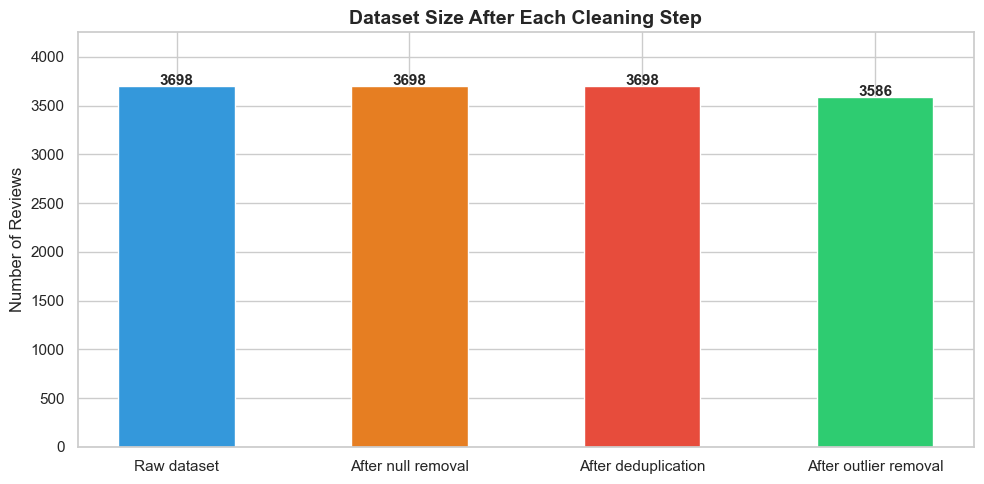

In [18]:
# Visual summary of cleaning steps
stages  = ['Raw dataset', 'After null removal', 'After deduplication', 'After outlier removal']
# recalculate these counts based on your earlier prints — update numbers after running
counts  = [3698, len(df) + too_short + too_long + duplicates.sum(), len(df) + too_short + too_long, len(df)]

colors = ['#3498db', '#e67e22', '#e74c3c', '#2ecc71']
plt.figure(figsize=(10, 5))
bars = plt.bar(stages, counts, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', fontsize=11, fontweight='bold')

plt.title('Dataset Size After Each Cleaning Step', fontsize=14, fontweight='bold')
plt.ylabel('Number of Reviews')
plt.ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.savefig('../reports/figures/cleaning_steps.png', dpi=150)
plt.show()

## 3. Combine Review Title + Review Text
The review title often contains key sentiment words - combining gives richer signal.

In [19]:
# Combine title and text into one field
df['full_review'] = df['review_title'].astype(str) + ' ' + df['review_text'].astype(str)

# Preview
df[['review_title', 'review_text', 'full_review']].head(3)

,review_title,review_text,full_review
0,Lowest price in the country,Lowest price in the country for what we wanted...,Lowest price in the country Lowest price in th...
1,got it on time they took notice that I…,got it on time they took notice that I let the...,got it on time they took notice that I… got it...
2,Delivered on time,"Delivered on time. Products as described, pack...",Delivered on time Delivered on time. Products ...


## 4. Text Cleaning Function
Remove URLs, HTML tags, special characters, numbers, and extra whitespace.

In [20]:
def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)        # remove URLs
    text = re.sub(r'<.*?>', '', text)                 # remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)              # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra spaces
    return text

# Apply
df['cleaned_text'] = df['full_review'].apply(clean_text)

# Preview
df[['full_review', 'cleaned_text']].head()

,full_review,cleaned_text
0,Lowest price in the country Lowest price in th...,lowest price in the country lowest price in th...
1,got it on time they took notice that I… got it...,got it on time they took notice that i got it ...
2,Delivered on time Delivered on time. Products ...,delivered on time delivered on time products a...
3,Quick and efficient service.. Quick and effici...,quick and efficient service quick and efficien...
4,Excellent service packed well Excellent servic...,excellent service packed well excellent servic...


## 5. Tokenization
Split cleaned text into individual word tokens.

In [21]:
def tokenize(text):
    return word_tokenize(text)

df['tokens'] = df['cleaned_text'].apply(tokenize)

# Preview
print("Sample tokens:")
print(df['tokens'][0])
print(f"\nAvg tokens per review: {df['tokens'].apply(len).mean():.1f}")

Sample tokens:
['lowest', 'price', 'in', 'the', 'country', 'lowest', 'price', 'in', 'the', 'country', 'for', 'what', 'we', 'wanted', 'cracking', 'value']

Avg tokens per review: 48.1


## 6. Stop-word Removal
Remove common words (the, is, and...) that carry no sentiment signal.

In [22]:
stop_words = set(stopwords.words('english'))

# Add custom stopwords relevant to review context
custom_stops = {'would', 'could', 'also', 'one', 'get', 'got', 'us', 'use'}
stop_words.update(custom_stops)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 2]

df['tokens_no_stop'] = df['tokens'].apply(remove_stopwords)

# Check how many words removed on average
avg_before = df['tokens'].apply(len).mean()
avg_after  = df['tokens_no_stop'].apply(len).mean()
print(f"Avg tokens before stopword removal : {avg_before:.1f}")
print(f"Avg tokens after stopword removal  : {avg_after:.1f}")
print(f"Words removed on average           : {avg_before - avg_after:.1f}")

Avg tokens before stopword removal : 48.1
Avg tokens after stopword removal  : 24.8
Words removed on average           : 23.3


## 7. Lemmatization
Reduce words to their root form: "running" -> "run", "services" -> "service".  
Using spaCy for accurate, context-aware lemmatization.

In [23]:
def lemmatize_tokens(tokens):
    # Join tokens -> spaCy doc -> extract lemmas
    doc = nlp(' '.join(tokens))
    return [token.lemma_ for token in doc]

df['tokens_lemmatized'] = df['tokens_no_stop'].apply(lemmatize_tokens)

# Preview transformation
sample_idx = 5
print("Original text    :", df['full_review'][sample_idx])
print("\nAfter cleaning   :", df['cleaned_text'][sample_idx])
print("\nAfter tokenize   :", df['tokens'][sample_idx])
print("\nAfter stopwords  :", df['tokens_no_stop'][sample_idx])
print("\nAfter lemmatize  :", df['tokens_lemmatized'][sample_idx])

Original text    : As this was my first order the delivery… As this was my first order the delivery was very quick and despite one of the goods broken, the response and a refund was quite quick, I will be using Poundshop in the very near future again.

After cleaning   : as this was my first order the delivery as this was my first order the delivery was very quick and despite one of the goods broken the response and a refund was quite quick i will be using poundshop in the very near future again

After tokenize   : ['as', 'this', 'was', 'my', 'first', 'order', 'the', 'delivery', 'as', 'this', 'was', 'my', 'first', 'order', 'the', 'delivery', 'was', 'very', 'quick', 'and', 'despite', 'one', 'of', 'the', 'goods', 'broken', 'the', 'response', 'and', 'a', 'refund', 'was', 'quite', 'quick', 'i', 'will', 'be', 'using', 'poundshop', 'in', 'the', 'very', 'near', 'future', 'again']

After stopwords  : ['first', 'order', 'delivery', 'first', 'order', 'delivery', 'quick', 'despite', 'goods', 'bro

## 8. Create Final Preprocessed Text Column
Join lemmatized tokens back into a string - this is the model input.

In [24]:
df['processed_text'] = df['tokens_lemmatized'].apply(lambda tokens: ' '.join(tokens))

# Quick check - no empty strings
empty_count = (df['processed_text'].str.strip() == '').sum()
print(f"Empty processed reviews: {empty_count}")

# Drop any empties if present
df = df[df['processed_text'].str.strip() != ''].reset_index(drop=True)

df[['full_review', 'processed_text', 'sentiment']].head(5)

Empty processed reviews: 1


,full_review,processed_text,sentiment
0,Lowest price in the country Lowest price in th...,low price country low price country want crack...,Positive
1,got it on time they took notice that I… got it...,time take notice time take notice let know go ...,Positive
2,Delivered on time Delivered on time. Products ...,deliver time deliver time product describe pac...,Positive
3,Quick and efficient service.. Quick and effici...,quick efficient service quick efficient servic...,Positive
4,Excellent service packed well Excellent servic...,excellent service pack well excellent service ...,Positive


## 9. Preprocessing Quality Check
Visualize token count before vs after preprocessing.

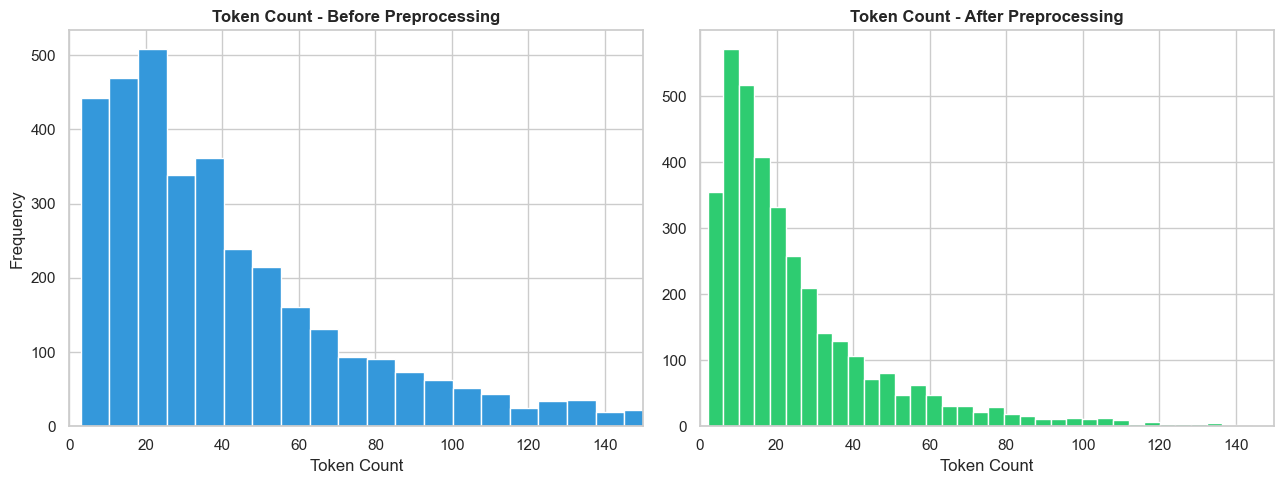

In [26]:
df['token_count_before'] = df['tokens'].apply(len)
df['token_count_after']  = df['tokens_lemmatized'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['token_count_before'], bins=40, color='#3498db', edgecolor='white')
axes[0].set_title('Token Count - Before Preprocessing', fontweight='bold')
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 150)

axes[1].hist(df['token_count_after'], bins=40, color='#2ecc71', edgecolor='white')
axes[1].set_title('Token Count - After Preprocessing', fontweight='bold')
axes[1].set_xlabel('Token Count')
axes[1].set_xlim(0, 150)

plt.tight_layout()
plt.savefig('../reports/figures/token_count_comparison.png', dpi=150)
plt.show()

## 10. Top 20 Most Frequent Words per Sentiment Class
Gives early insight into what words drive positive vs negative reviews.

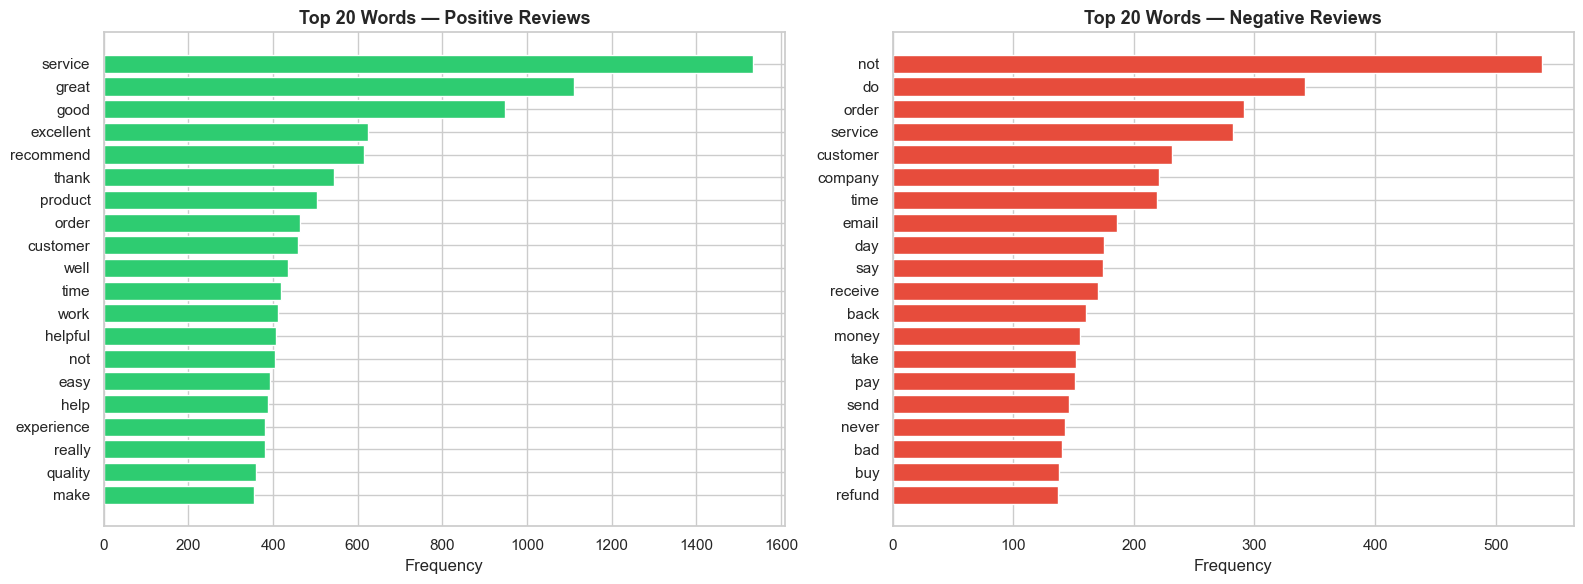

In [27]:
def top_words(sentiment_label, n=20):
    tokens = df[df['sentiment'] == sentiment_label]['tokens_lemmatized'].sum()
    return Counter(tokens).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, color in zip(axes, ['Positive', 'Negative'], ['#2ecc71', '#e74c3c']):
    words, counts = zip(*top_words(label))
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 20 Words — {label} Reviews', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/figures/top_words_by_sentiment.png', dpi=150)
plt.show()

## 11. Encode Sentiment Labels for Modeling
Convert string labels to integers: Positive=2, Neutral=1, Negative=0

In [28]:
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['label'] = df['sentiment'].map(label_map)

print("Label distribution:")
print(df['label'].value_counts().sort_index())
print("\nMapping:", label_map)

Label distribution:
label
0     648
1      64
2    2873
Name: count, dtype: int64

Mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}


## 12. Save Cleaned Dataset

In [29]:
# Keep only the columns needed for modeling
cols_to_save = [
    'name', 'author_name', 'review_title', 'review_text',
    'full_review', 'processed_text', 'rating', 'sentiment',
    'label', 'review_length', 'token_count_after', 'reviewed_at'
]

df_clean = df[cols_to_save]
df_clean.to_csv('../data/processed/reviews_cleaned.csv', index=False)

print(f"Saved reviews_cleaned.csv")
print(f"   Rows    : {len(df_clean)}")
print(f"   Columns : {df_clean.shape[1]}")
print(f"\nSentiment breakdown:")
print(df_clean['sentiment'].value_counts())

Saved reviews_cleaned.csv
   Rows    : 3585
   Columns : 12

Sentiment breakdown:
sentiment
Positive    2873
Negative     648
Neutral       64
Name: count, dtype: int64


## Preprocessing Summary

| Step | Method | Tool |
|---|---|---|
| Cleaning | Lowercase, remove URLs, HTML, symbols | `re` |
| Tokenization | Word-level split | `nltk.word_tokenize` |
| Stop-word removal | English stopwords + custom list | `nltk.stopwords` |
| Lemmatization | Root form extraction | `spaCy en_core_web_sm` |
| Label encoding | Negative=0, Neutral=1, Positive=2 | manual map |

**Output saved to:** `data/processed/reviews_cleaned.csv`  
**Next -> `03_ml_models.ipynb` for TF-IDF + traditional ML classification**